In [131]:
from tqdm import tqdm
import numpy as np
import importlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

def bimodal(S=1, mu=1, sigma=1):
    choose_left = np.random.randint(2, size=S)
    z = np.random.normal(0, sigma, S)
    means = np.where(choose_left == 1, mu - 2, mu + 2)
    if S == 1: return means[0] + z[0]
    return (means + z)

def bimodal_cdf(x, mu=1, sigma=1):
    return 0.5 * norm.cdf(x, mu-2, sigma) + 0.5 * norm.cdf(x, mu+2, sigma)

def bimodal_ppf(q, mu=1, sigma=1, x_min=-20, x_max=20):
    q = np.asarray(q)
    def solve_one(qi):
        if qi <= 0.0:
            return x_min
        if qi >= 1.0:
            return x_max
        f = lambda x: bimodal_cdf(x, mu, sigma) - qi
        return brentq(f, x_min, x_max)
    return np.vectorize(solve_one)(q)

def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

n_runs = 5
N = 256
n_episodes = 20_000
save_skip = 100
alpha = 0.2
scheduler = get_exp_scheduler(alpha, 1250, min_val=0.0001)
tau = (np.arange(N) + 0.5) / N

def run_simple(reward_func, use_huber=False):
    gamma = 1.0
    thetas = np.zeros((n_runs, n_episodes//save_skip, N))
    qtables = np.zeros((n_runs, n_episodes//save_skip, 1))
    
    for n in tqdm(range(n_runs)):
        theta = np.zeros(N)
        qtable = 0.0
        
        for t in range(n_episodes):
            lr = scheduler(t)
            
            Ttheta = reward_func() + gamma * np.zeros(N) # No future state
            u = ((Ttheta[:, None] - theta[None, :]))

            if use_huber: rho = -np.abs(tau - (u < 0)).mean(0) * du_huber(u.mean(0))
            else:         rho = -(tau - (u < 0)).mean(0)
            theta -= lr * rho

            uQ = reward_func() + gamma * 0.0 - qtable
            qtable += lr * uQ
            
            if t % save_skip == 0:
                thetas[n, t//save_skip] = theta.copy()
                qtables[n, t//save_skip] = qtable
    return thetas, qtables

table0, qtable = run_simple(bimodal, use_huber=False)
table1, _ = run_simple(bimodal, use_huber=True)

100%|██████████| 5/5 [00:20<00:00,  4.10s/it]


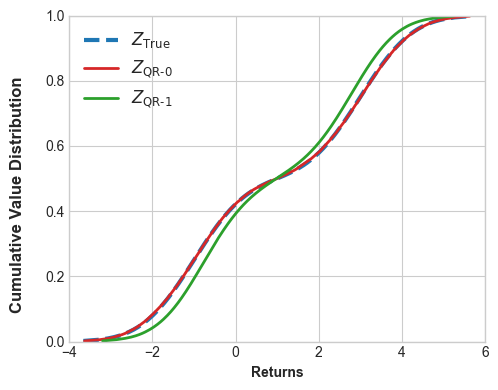

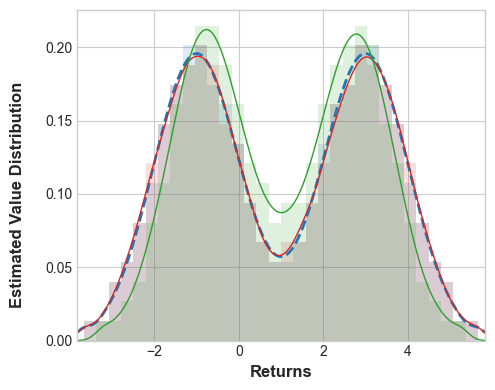

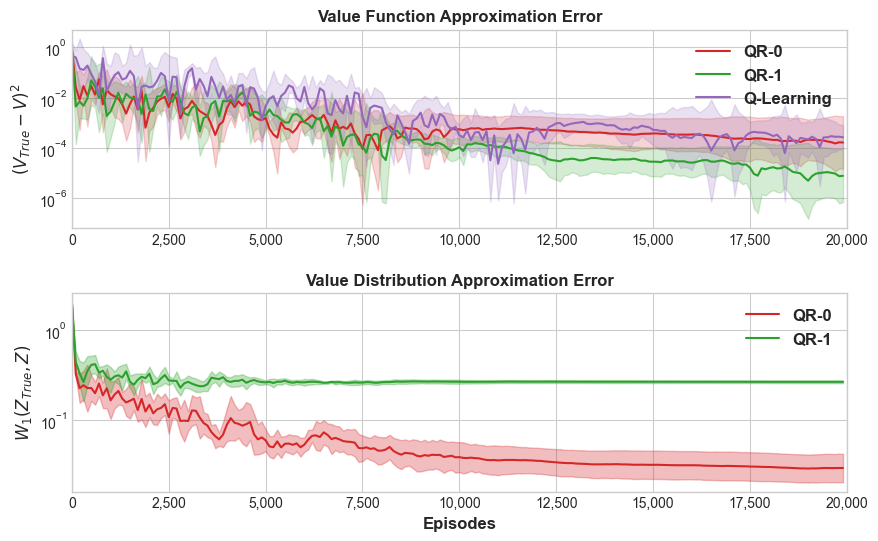

In [134]:
import analysis
importlib.reload(analysis)
from analysis import *

tau_true = bimodal_ppf(tau)

save_to = "results/results/simplest_mu1"

plot_objs = [
    (table0.mean(0)[-1], r"$Z_{\text{QR-0}}$"),
    (table1.mean(0)[-1], r"$Z_{\text{QR-1}}$"),
]
plot_cdf(plot_objs, tau_true, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{True}}$")
plt.xlim(-4.0,6.0)

plot_pdf(plot_objs, tau_true, bandwidth=0.2, show_hist=True, hist_alpha=0.15, save_to=save_to)

plot_qs = [
    (table0, "QR-0"),
    (table1, "QR-1"),
    (qtable, "Q-Learning"),
]
plot_metrics(plot_qs, tau_true, save_skip=save_skip, save_to=save_to, alphas=(0.2,0.3))